## Looking at the TISMO dataset 

In [7]:
import pandas as pd

GSE124821_df = pd.read_csv("/Users/manoharan/Desktop/MIB MP/GSE124821_data.csv")

In [8]:
GSE124821_df


,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,GSM_ID,Cell_Line
0,SRX5100689,0.020644,0.007343,0.003824,0.005128,antiPD1; antiCTLA4;,day7,day7,GSM3554691,KPB25L
1,SRX5100686,0.030451,0.010853,0.000000,0.003228,no_treatment,day7,day7,GSM3554692,KPB25L
2,SRX5100687,0.030096,0.010989,0.000349,0.004048,no_treatment,day7,day7,GSM3554693,KPB25L
3,SRX5100692,0.030466,0.010471,0.000333,0.004030,no_treatment,day7,day7,GSM3554694,KPB25L
4,SRX5100693,0.031649,0.008606,0.000000,0.003357,no_treatment,day7,day7,GSM3554695,KPB25L
...,...,...,...,...,...,...,...,...,...,...
187,SRX5100807,0.032076,0.012687,0.000000,0.004420,antiPD1; antiCTLA4;,end,end,GSM3554932,T11
188,SRX5100814,0.027448,0.011238,0.000000,0.004636,antiPD1; antiCTLA4;,end,end,GSM3554933,T11
189,SRX5100813,0.021779,0.009103,0.000000,0.003387,no_treatment,end,end,GSM3554934,T11
190,SRX5100812,0.029557,0.013101,0.000407,0.005049,no_treatment,end,end,GSM3554935,T11


In [15]:

KPB25L_notreatment_df = GSE124821_df[
    (df['Mouse_treatment'] == 'no_treatment') &
    (df['Cell_Line'] == 'KPB25L') 
]

KPB25L_notreatment_df

,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,GSM_ID,Cell_Line
1,SRX5100686,0.030451,0.010853,0.000000,0.003228,no_treatment,day7,day7,GSM3554692,KPB25L
2,SRX5100687,0.030096,0.010989,0.000349,0.004048,no_treatment,day7,day7,GSM3554693,KPB25L
3,SRX5100692,0.030466,0.010471,0.000333,0.004030,no_treatment,day7,day7,GSM3554694,KPB25L
4,SRX5100693,0.031649,0.008606,0.000000,0.003357,no_treatment,day7,day7,GSM3554695,KPB25L
8,SRX5100597,0.029152,0.007065,0.000000,0.002797,no_treatment,end,end,GSM3554699,KPB25L
9,SRX5100596,0.032315,0.010025,0.000000,0.003605,no_treatment,day3,day3,GSM3554700,KPB25L
10,SRX5100599,0.025473,0.006424,0.000000,0.002765,no_treatment,end,end,GSM3554701,KPB25L
11,SRX5100598,0.025723,0.007226,0.000000,0.003291,no_treatment,day3,day3,GSM3554702,KPB25L
12,SRX5100618,0.025649,0.005015,0.000000,0.002848,no_treatment,day3,day3,GSM3554703,KPB25L
13,SRX5100617,0.027570,0.007122,0.000000,0.003442,no_treatment,day3,day3,GSM3554704,KPB25L



Number of replicates 5
Dendritic_quanTIseq    0.030802
NK_quanTIseq           0.007164
T.CD8_quanTIseq        0.000000
Tregs_quanTIseq        0.003942
dtype: float64
<class 'pandas.Series'>

Number of replicates 4
Dendritic_quanTIseq    0.030666
NK_quanTIseq           0.010230
T.CD8_quanTIseq        0.000171
Tregs_quanTIseq        0.003666
dtype: float64
<class 'pandas.Series'>

Number of replicates 6
Dendritic_quanTIseq    0.024924
NK_quanTIseq           0.006209
T.CD8_quanTIseq        0.000000
Tregs_quanTIseq        0.002772
dtype: float64
<class 'pandas.Series'>


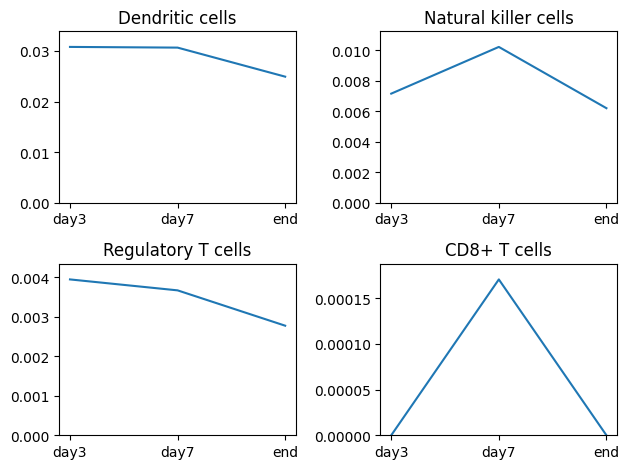

In [ ]:
import matplotlib.pyplot as plt
quanTIseq_cols = ["Dendritic_quanTIseq","NK_quanTIseq","T.CD8_quanTIseq","Tregs_quanTIseq"]
Ds = []
NKs = []
T8s = []
Tregs = []

for day in ["day3","day7","end"]:
    day_df = KPB25L_notreatment_df[KPB25L_notreatment_df['Condition'] == day]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    print(averages)
    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    Ds.append(averages["Dendritic_quanTIseq"])
    NKs.append(averages["NK_quanTIseq"])
    T8s.append(averages["T.CD8_quanTIseq"])
    Tregs.append(averages["Tregs_quanTIseq"])

time_points = ["day3","day7","end"]

fig,ax = plt.subplots(2,2)

Dplot = ax[0,0]
Dplot.plot(time_points,Ds)
Dplot.set_title('Dendritic cells')
Dplot.set_ylim(0.0,max(Ds)*1.1)
NKplot = ax[0,1]
NKplot.plot(time_points,NKs)
NKplot.set_title('Natural killer cells')
NKplot.set_ylim(0.0,max(NKs)*1.1)

Tregplot = ax[1,0]
Tregplot.plot(time_points,Tregs)
Tregplot.set_title('Regulatory T cells')
Tregplot.set_ylim(0.0,max(Tregs)*1.1)

T8plot = ax[1,1]
T8plot.plot(time_points,T8s)
T8plot.set_title('CD8+ T cells')
T8plot.set_ylim(0.0,max(T8s)*1.1)

plt.tight_layout()
plt.show()

In [17]:
UV_Ds = []
UV_NKs = []
UV_T8s = []
UV_Tregs = []

for day in ["UV_day3","UV_day7","UV_end"]:
    day_df = KPB25L_notreatment_df[KPB25L_notreatment_df['Condition'] == day]
    averages = day_df.filter(items=quanTIseq_cols).mean()

    UV_Ds.append(averages["Dendritic_quanTIseq"])
    UV_NKs.append(averages["NK_quanTIseq"])
    UV_T8s.append(averages["T.CD8_quanTIseq"])
    UV_Tregs.append(averages["Tregs_quanTIseq"])


In [22]:
AP_Ds = []
AP_NKs = []
AP_T8s = []
AP_Tregs = []

day = "Apobec_day3"
day_df = KPB25L_notreatment_df[KPB25L_notreatment_df['Condition'] == day]
averages = day_df.filter(items=quanTIseq_cols).mean()

AP_Ds.append(averages["Dendritic_quanTIseq"])
AP_NKs.append(averages["NK_quanTIseq"])
AP_T8s.append(averages["T.CD8_quanTIseq"])
AP_Tregs.append(averages["Tregs_quanTIseq"])


In [23]:
time_points = ["day3","day7","end"]


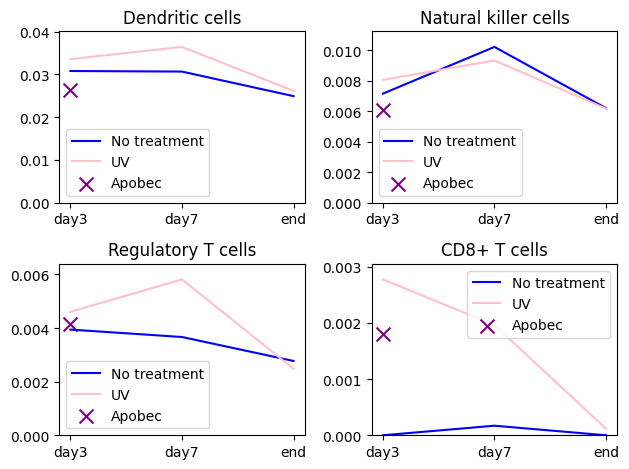

In [24]:
fig,ax = plt.subplots(2,2)

# Dendritic cells
Dplot = ax[0,0]
Dplot.plot(time_points, Ds, label="No treatment", color="blue")
Dplot.plot(time_points, UV_Ds, label="UV", color="pink")
Dplot.scatter(["day3"], AP_Ds, color="purple", marker="x", s=100, label="Apobec")
Dplot.set_title('Dendritic cells')
Dplot.set_ylim(0.0, max(Ds + UV_Ds + AP_Ds)*1.1)
Dplot.legend()

# NK cells
NKplot = ax[0,1]
NKplot.plot(time_points, NKs, label="No treatment", color="blue")
NKplot.plot(time_points, UV_NKs, label="UV", color="pink")
NKplot.scatter(["day3"], AP_NKs, color="purple", marker="x", s=100, label="Apobec")
NKplot.set_title('Natural killer cells')
NKplot.set_ylim(0.0, max(NKs + UV_NKs + AP_NKs)*1.1)
NKplot.legend()

# Tregs
Tregplot = ax[1,0]
Tregplot.plot(time_points, Tregs, label="No treatment", color="blue")
Tregplot.plot(time_points, UV_Tregs, label="UV", color="pink")
Tregplot.scatter(["day3"], AP_Tregs, color="purple", marker="x", s=100, label="Apobec")
Tregplot.set_title('Regulatory T cells')
Tregplot.set_ylim(0.0, max(Tregs + UV_Tregs + AP_Tregs)*1.1)
Tregplot.legend()

# CD8 T cells
T8plot = ax[1,1]
T8plot.plot(time_points, T8s, label="No treatment", color="blue")
T8plot.plot(time_points, UV_T8s, label="UV", color="pink")
T8plot.scatter(["day3"], AP_T8s, color="purple", marker="x", s=100, label="Apobec")
T8plot.set_title('CD8+ T cells')
T8plot.set_ylim(0.0, max(T8s + UV_T8s + AP_T8s)*1.1)
T8plot.legend()

plt.tight_layout()
plt.show()


## Plotting the standard deviations and mean

In [25]:
Ds, NKs, T8s, Tregs = [], [], [], []
Ds_std, NKs_std, T8s_std, Tregs_std = [], [], [], []

for day in ["day3","day7","end"]:
    day_df = KPB25L_notreatment_df[KPB25L_notreatment_df['Condition'] == day]
    means = day_df.filter(items=quanTIseq_cols).mean()
    stds  = day_df.filter(items=quanTIseq_cols).std()

    Ds.append(means["Dendritic_quanTIseq"])
    NKs.append(means["NK_quanTIseq"])
    T8s.append(means["T.CD8_quanTIseq"])
    Tregs.append(means["Tregs_quanTIseq"])

    Ds_std.append(stds["Dendritic_quanTIseq"])
    NKs_std.append(stds["NK_quanTIseq"])
    T8s_std.append(stds["T.CD8_quanTIseq"])
    Tregs_std.append(stds["Tregs_quanTIseq"])


In [28]:
UV_Ds, UV_NKs, UV_T8s, UV_Tregs = [], [], [], []
UV_Ds_std, UV_NKs_std, UV_T8s_std, UV_Tregs_std = [], [], [], []

for day in ["UV_day3","UV_day7","UV_end"]:
    day_df = KPB25L_notreatment_df[KPB25L_notreatment_df['Condition'] == day]
    means = day_df.filter(items=quanTIseq_cols).mean()
    stds  = day_df.filter(items=quanTIseq_cols).std()

    UV_Ds.append(means["Dendritic_quanTIseq"])
    UV_NKs.append(means["NK_quanTIseq"])
    UV_T8s.append(means["T.CD8_quanTIseq"])
    UV_Tregs.append(means["Tregs_quanTIseq"])

    UV_Ds_std.append(stds["Dendritic_quanTIseq"])
    UV_NKs_std.append(stds["NK_quanTIseq"])
    UV_T8s_std.append(stds["T.CD8_quanTIseq"])
    UV_Tregs_std.append(stds["Tregs_quanTIseq"])


In [37]:
AP_Ds = []
AP_NKs = []
AP_T8s = []
AP_Tregs = []

AP_Ds_std = []
AP_NKs_std = []
AP_T8s_std = []
AP_Tregs_std = []

day = "Apobec_day3"
day_df = KPB25L_notreatment_df[KPB25L_notreatment_df['Condition'] == day]
means = day_df.filter(items=quanTIseq_cols).mean()
stds  = day_df.filter(items=quanTIseq_cols).std()

AP_Ds.append(means["Dendritic_quanTIseq"])
AP_NKs.append(means["NK_quanTIseq"])
AP_T8s.append(means["T.CD8_quanTIseq"])
AP_Tregs.append(means["Tregs_quanTIseq"])

AP_Ds_std.append(stds["Dendritic_quanTIseq"])
AP_NKs_std.append(stds["NK_quanTIseq"])
AP_T8s_std.append(stds["T.CD8_quanTIseq"])
AP_Tregs_std.append(stds["Tregs_quanTIseq"])


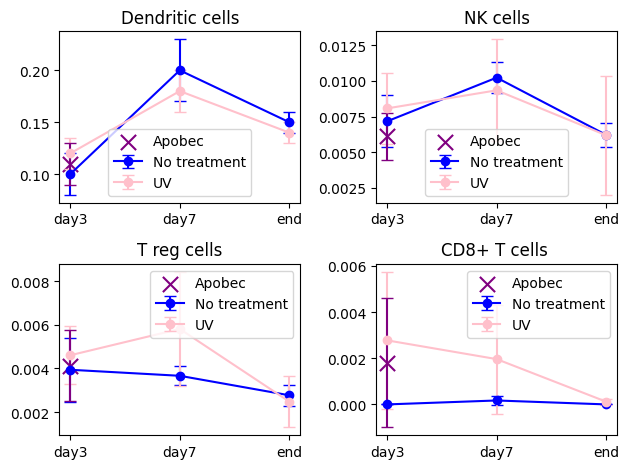

In [36]:
import matplotlib.pyplot as plt

time_points = ["day3","day7","end"]

# Example data (replace with your real lists)
Ds = [0.1, 0.2, 0.15]
Ds_std = [0.02, 0.03, 0.01]

UV_Ds = [0.12, 0.18, 0.14]
UV_Ds_std = [0.015, 0.02, 0.01]

AP_Ds = [0.11]          # only day3
AP_Ds_std = [0.02]

fig, ax = plt.subplots(2,2)

Dplot = ax[0,0]
# No treatment
Dplot.errorbar(time_points, Ds, yerr=Ds_std, label="No treatment",
               color="blue", marker="o", capsize=4)
# UV
Dplot.errorbar(time_points, UV_Ds, yerr=UV_Ds_std, label="UV",
               color="pink", marker="o", capsize=4)
# Apobec (only day3)
Dplot.scatter(["day3"], AP_Ds, color="purple", marker="x", s=120, label="Apobec")
Dplot.errorbar(["day3"], AP_Ds, yerr=AP_Ds_std, color="purple", capsize=4)

Dplot.set_title("Dendritic cells")
Dplot.legend()


# NK cells
NKplot = ax[0,1]
# No treatment
NKplot.errorbar(time_points, NKs, yerr=NKs_std, label="No treatment",
               color="blue", marker="o", capsize=4)
# UV
NKplot.errorbar(time_points, UV_NKs, yerr=UV_NKs_std, label="UV",
               color="pink", marker="o", capsize=4)
# Apobec (only day3)
NKplot.scatter(["day3"], AP_NKs, color="purple", marker="x", s=120, label="Apobec")
NKplot.errorbar(["day3"], AP_NKs, yerr=AP_NKs_std, color="purple", capsize=4)

NKplot.set_title("NK cells")
NKplot.legend()



# Tregs
Tregsplot = ax[1,0]
# No treatment
Tregsplot.errorbar(time_points, Tregs, yerr=Tregs_std, label="No treatment",
               color="blue", marker="o", capsize=4)
# UV
Tregsplot.errorbar(time_points, UV_Tregs, yerr=UV_Tregs_std, label="UV",
               color="pink", marker="o", capsize=4)
# Apobec (only day3)
Tregsplot.scatter(["day3"], AP_Tregs, color="purple", marker="x", s=120, label="Apobec")
Tregsplot.errorbar(["day3"], AP_Tregs, yerr=AP_Tregs_std, color="purple", capsize=4)
Tregsplot.set_title("T reg cells")
Tregsplot.legend()

# CD8 T cells
T8plot = ax[1,1]
# No treatment
T8plot.errorbar(time_points, T8s, yerr=T8s_std, label="No treatment",
               color="blue", marker="o", capsize=4)
# UV
T8plot.errorbar(time_points, UV_T8s, yerr=UV_T8s_std, label="UV",
               color="pink", marker="o", capsize=4)
# Apobec (only day3)
T8plot.scatter(["day3"], AP_T8s, color="purple", marker="x", s=120, label="Apobec")
T8plot.errorbar(["day3"], AP_T8s, yerr=AP_T8s_std, color="purple", capsize=4)

T8plot.set_title("CD8+ T cells ")
T8plot.legend()

plt.tight_layout()
plt.show()
